# Forecasting with TimeXer — M5 Forecasting Accuracy (28-day holdout)

This notebook adapts the **same evaluation philosophy** used in the Chronos-2 M5 notebook to a **supervised TimeXer pipeline**.

It assumes you already generated these processed CSVs:

- `dataset/processed/m5_context.csv`
- `dataset/processed/m5_future.csv`
- `dataset/processed/m5_actuals.csv`

## Objective
Train **TimeXer** on the historical M5 panel and forecast the same **28-day holdout** used by Chronos-2.

## Comparable evaluation design
- **Same target**: daily unit sales (`target`)
- **Same series IDs**: `id = item_id + "_" + store_id`
- **Same holdout**: `m5_future.csv` vs `m5_actuals.csv`
- **Same metrics**: **MAE, RMSE, sMAPE, WAPE, MASE, WQL**
- **Same visual analyses**: per-series distributions, horizon curves, representative series, and aggregated demand

## Important note on comparability
Chronos-2 is **zero-shot** and can consume a very long context directly.
TimeXer is **supervised** and requires a fixed encoder length during training/inference.
To keep the experiment tractable while remaining fair, this notebook uses:

- one fixed subset of series (reused from `m5_selected_ids.csv` if available)
- a configurable fixed encoder length
- a validation tail taken from the end of `m5_context.csv`
- the untouched future holdout for final evaluation

In [19]:
%pip install -q "pytorch-forecasting>=1.4" lightning pandas numpy matplotlib seaborn

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import lightning.pytorch as pl

from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.models.timexer import TimeXer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE, SMAPE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "dataset/processed"
CONTEXT_PATH = os.path.join(DATA_DIR, "m5_context.csv")
FUTURE_PATH = os.path.join(DATA_DIR, "m5_future.csv")
ACTUALS_PATH = os.path.join(DATA_DIR, "m5_actuals.csv")

# ---------------------------
# Main configuration
# ---------------------------
PREDICTION_LENGTH = 28
ENCODER_LENGTH = 1456          # 52 weeks of daily history - bk 364
PATCH_LENGTH = 7              # 1 week per patch
VAL_LENGTH = 28               # last 28 historical days used for validation
TRAIN_HISTORY_DAYS = 8192      # None -> keep all historical rows before training - initial 730
MAX_SERIES = 500              # None -> use all selected/available series
SERIES_SELECTION = "dense_random"   # {"dense_random", "random", "top_total_sales"}
RANDOM_SEED = 42
REUSE_SELECTED_IDS = True
SELECTED_IDS_PATH = os.path.join(DATA_DIR, "m5_selected_ids.csv")

BATCH_SIZE = 128
MAX_EPOCHS = 50
PATIENCE = 4
LEARNING_RATE = 1e-4
HIDDEN_SIZE = 512
N_HEADS = 4
E_LAYERS = 2
D_FF = 1024
DROPOUT = 0.1

QUANTILE_LEVELS = [0.1, 0.5, 0.9]
MASE_SEASONALITY = 7          # daily retail -> weekly seasonal naive baseline
CLIP_PREDICTIONS_AT_ZERO = True

pl.seed_everything(RANDOM_SEED, workers=True)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available : {hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()}")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


Seed set to 42


Note: you may need to restart the kernel to use updated packages.
PyTorch: 2.11.0
CUDA available: False
MPS available : True


## 1. Load the processed CSVs

This notebook does **not** rebuild the raw Kaggle files.
It starts from the processed M5 panel prepared in your dataset notebook.

In [20]:
for path in [CONTEXT_PATH, FUTURE_PATH, ACTUALS_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

context_df = pd.read_csv(CONTEXT_PATH, parse_dates=["timestamp"])
future_df = pd.read_csv(FUTURE_PATH, parse_dates=["timestamp"])
actuals_df = pd.read_csv(ACTUALS_PATH, parse_dates=["timestamp"])

print("CSV files loaded correctly:")
print(f"- context: {context_df.shape[0]:,} rows, {context_df.shape[1]} columns")
print(f"- future : {future_df.shape[0]:,} rows, {future_df.shape[1]} columns")
print(f"- actuals: {actuals_df.shape[0]:,} rows, {actuals_df.shape[1]} columns")
print()
print(f"Series in context: {context_df['id'].nunique():,}")
print(f"Series in future : {future_df['id'].nunique():,}")
print(f"Series in actuals: {actuals_df['id'].nunique():,}")
print()
print(f"Historical range: {context_df['timestamp'].min()} -> {context_df['timestamp'].max()}")
print(f"Holdout range   : {future_df['timestamp'].min()} -> {future_df['timestamp'].max()}")

display(context_df.head())

CSV files loaded correctly:
- context: 58,327,370 rows, 9 columns
- future : 853,720 rows, 8 columns
- actuals: 853,720 rows, 3 columns

Series in context: 30,490
Series in future : 30,490
Series in actuals: 30,490

Historical range: 2011-01-29 00:00:00 -> 2016-04-24 00:00:00
Holdout range   : 2016-04-25 00:00:00 -> 2016-05-22 00:00:00


,id,timestamp,target,sell_price,snap,wday,month,event_any,event_type_main
0,FOODS_1_001_CA_1,2011-01-29,3,2.0,0.0,1,1,0,NaN
1,FOODS_1_001_CA_1,2011-01-30,0,2.0,0.0,2,1,0,NaN
2,FOODS_1_001_CA_1,2011-01-31,0,2.0,0.0,3,1,0,NaN
3,FOODS_1_001_CA_1,2011-02-01,1,2.0,1.0,4,2,0,NaN
4,FOODS_1_001_CA_1,2011-02-02,4,2.0,1.0,5,2,0,NaN


## 2. Reuse the same series subset as Chronos-2

To compare Chronos-2 and TimeXer fairly, both models should run on **the same series IDs**.

This cell:

- loads `m5_selected_ids.csv` if it already exists and reuse is enabled
- otherwise creates it once
- filters `context_df`, `future_df`, and `actuals_df` with the same IDs

In [21]:
import os
import pandas as pd
import numpy as np

# ============================================================
# SERIES SUBSET CONFIG
# ============================================================
RANDOM_SEED = 42

# For dense_random:
# keep only the densest X% of series, then sample randomly from them
DENSE_QUANTILE = 0.75   # 0.75 = top 25% densest series
DENSITY_METRIC = "nonzero_ratio"  # recommended for M5

# Save different subset files depending on the strategy
SELECTED_IDS_PATH = (
    f"dataset/processed/m5_selected_ids__{SERIES_SELECTION}"
    f"__n{MAX_SERIES}"
    f"__q{int(DENSE_QUANTILE*100)}"
    f"__seed{RANDOM_SEED}.csv"
)

# ============================================================
# BUILD SERIES-LEVEL STATS FROM FULL CONTEXT
# ============================================================
series_stats_full = (
    context_df.groupby("id")
    .agg(
        total_sales=("target", "sum"),
        mean_sales=("target", "mean"),
        median_sales=("target", "median"),
        nonzero_days=("target", lambda s: int((s > 0).sum())),
        n_days=("target", "size"),
    )
    .reset_index()
)

series_stats_full["nonzero_ratio"] = (
        series_stats_full["nonzero_days"] / series_stats_full["n_days"]
)

all_ids = series_stats_full["id"].drop_duplicates().sort_values().reset_index(drop=True)

# ============================================================
# CREATE OR LOAD FIXED SUBSET OF IDS
# ============================================================
if MAX_SERIES is None:
    selected_ids = all_ids.copy()
    print(f"MAX_SERIES=None -> using all {len(selected_ids)} series")

else:
    if os.path.exists(SELECTED_IDS_PATH):
        selected_ids = pd.read_csv(SELECTED_IDS_PATH)["id"].drop_duplicates().reset_index(drop=True)
        print(f"Loaded existing selected IDs from: {SELECTED_IDS_PATH}")
        print(f"Loaded {len(selected_ids)} series")

    else:
        if SERIES_SELECTION == "random":
            selected_ids = (
                all_ids.sample(n=MAX_SERIES, random_state=RANDOM_SEED)
                .sort_values()
                .reset_index(drop=True)
            )

        elif SERIES_SELECTION == "top_total_sales":
            selected_ids = (
                series_stats_full.sort_values("total_sales", ascending=False)
                .head(MAX_SERIES)["id"]
                .sort_values()
                .reset_index(drop=True)
            )

        elif SERIES_SELECTION == "dense_random":
            if DENSITY_METRIC not in series_stats_full.columns:
                raise ValueError(
                    f"DENSITY_METRIC='{DENSITY_METRIC}' not found. "
                    f"Available: {series_stats_full.columns.tolist()}"
                )

            density_threshold = series_stats_full[DENSITY_METRIC].quantile(DENSE_QUANTILE)

            dense_pool = series_stats_full[
                series_stats_full[DENSITY_METRIC] >= density_threshold
                ].copy()

            if len(dense_pool) < MAX_SERIES:
                raise ValueError(
                    f"Dense pool too small: only {len(dense_pool)} eligible series, "
                    f"but MAX_SERIES={MAX_SERIES}. "
                    f"Lower DENSE_QUANTILE or reduce MAX_SERIES."
                )

            selected_ids = (
                dense_pool["id"]
                .sample(n=MAX_SERIES, random_state=RANDOM_SEED)
                .sort_values()
                .reset_index(drop=True)
            )

            print(f"Dense sampling using metric='{DENSITY_METRIC}'")
            print(f"Density threshold at quantile {DENSE_QUANTILE:.2f}: {density_threshold:.6f}")
            print(f"Dense pool size: {len(dense_pool)}")

        else:
            raise ValueError("SERIES_SELECTION must be 'random', 'dense_random', or 'top_total_sales'")

        pd.DataFrame({"id": selected_ids}).to_csv(SELECTED_IDS_PATH, index=False)
        print(f"Created and saved selected IDs to: {SELECTED_IDS_PATH}")
        print(f"Saved {len(selected_ids)} series using selection='{SERIES_SELECTION}'")

# ============================================================
# FILTER ALL DATAFRAMES WITH THE SAME IDS
# ============================================================
selected_ids_set = set(selected_ids)

context_df = context_df[context_df["id"].isin(selected_ids_set)].copy()
future_df  = future_df[future_df["id"].isin(selected_ids_set)].copy()
actuals_df = actuals_df[actuals_df["id"].isin(selected_ids_set)].copy()

# Deterministic order
context_df = context_df.sort_values(["id", "timestamp"]).reset_index(drop=True)
future_df  = future_df.sort_values(["id", "timestamp"]).reset_index(drop=True)
actuals_df = actuals_df.sort_values(["id", "timestamp"]).reset_index(drop=True)

# ============================================================
# REPORT THE SELECTED SUBSET
# ============================================================
selected_stats = (
    series_stats_full[series_stats_full["id"].isin(selected_ids_set)]
    .sort_values([DENSITY_METRIC if DENSITY_METRIC in series_stats_full.columns else "total_sales"], ascending=False)
    .reset_index(drop=True)
)

print("\nFiltered shapes:")
print("context_df:", context_df.shape)
print("future_df :", future_df.shape)
print("actuals_df:", actuals_df.shape)

print("\nUnique series after filtering:")
print("context_df:", context_df["id"].nunique())
print("future_df :", future_df["id"].nunique())
print("actuals_df:", actuals_df["id"].nunique())

print("\nSelected subset summary:")
display(
    selected_stats[["id", "nonzero_days", "n_days", "nonzero_ratio", "mean_sales", "total_sales"]]
    .head(10)
)

print("\nDense subset descriptive stats:")
display(
    selected_stats[["nonzero_ratio", "mean_sales", "total_sales"]]
    .describe()
)

Loaded existing selected IDs from: dataset/processed/m5_selected_ids__dense_random__n500__q75__seed42.csv
Loaded 500 series

Filtered shapes:
context_df: (956500, 9)
future_df : (14000, 8)
actuals_df: (14000, 3)

Unique series after filtering:
context_df: 500
future_df : 500
actuals_df: 500

Selected subset summary:


,id,nonzero_days,n_days,nonzero_ratio,mean_sales,total_sales
0,FOODS_3_555_CA_2,1906,1913,0.996341,16.205436,31001
1,FOODS_3_080_WI_1,1906,1913,0.996341,12.945635,24765
2,FOODS_3_694_WI_3,1906,1913,0.996341,44.763722,85633
3,FOODS_3_714_CA_3,1905,1913,0.995818,27.126503,51893
4,FOODS_3_694_WI_1,1904,1913,0.995295,21.551490,41228
5,FOODS_3_668_WI_2,1893,1913,0.989545,7.618923,14575
6,FOODS_3_714_CA_2,1890,1913,0.987977,10.853110,20762
7,FOODS_3_473_TX_3,1882,1913,0.983795,5.991636,11462
8,FOODS_3_228_TX_1,1874,1913,0.979613,6.920544,13239
9,FOODS_1_018_CA_1,1860,1913,0.972295,9.706221,18568



Dense subset descriptive stats:


,nonzero_ratio,mean_sales,total_sales
count,500.000000,500.000000,500.000000
mean,0.647129,3.295940,6305.134000
std,0.136041,4.114742,7871.501574
min,0.463147,0.709357,1357.000000
25%,0.533717,1.273001,2435.250000
50%,0.625719,1.944328,3719.500000
75%,0.731312,3.619707,6924.500000
max,0.996341,44.763722,85633.000000


## 3. Define target, covariates, and panel preparation

For M5 in this notebook:

- **Target**: `target` = daily unit sales
- **ID**: `id`
- **Timestamp**: `timestamp`

### TimeXer covariate modeling
We keep the M5 covariates close to the Chronos-2 notebook:

- **Known future real-valued covariates**:
  - `sell_price`
- **Known future categorical covariates**:
  - `snap`
  - `wday`
  - `month`
  - `event_any`
  - `event_type_main`

There are no extra past-only exogenous variables in this processed version, so the only unknown real target sequence is `target`.

In [22]:
TARGET = "target"
ID_COL = "id"
TS_COL = "timestamp"

TIME_VARYING_KNOWN_REALS = ["sell_price"]
TIME_VARYING_KNOWN_CATEGORICALS = ["snap", "wday", "month", "event_any", "event_type_main"]
PAST_ONLY_COVARIATES = []

def prepare_panel(df, has_target=True):
    df = df.copy()
    df[TS_COL] = pd.to_datetime(df[TS_COL])

    if has_target and TARGET in df.columns:
        df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").fillna(0.0).astype(float)

    if "sell_price" in df.columns:
        df["sell_price"] = pd.to_numeric(df["sell_price"], errors="coerce")

    for col in ["snap", "wday", "month", "event_any"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int).astype(str)

    if "event_type_main" in df.columns:
        df["event_type_main"] = df["event_type_main"].fillna("NoEvent").astype(str)

    df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)
    return df

context_df = prepare_panel(context_df, has_target=True)
future_df = prepare_panel(future_df, has_target=False)
actuals_df = prepare_panel(actuals_df, has_target=True)

def fill_sell_price(context_df, future_df):
    context_df = context_df.copy()
    future_df = future_df.copy()

    context_df["sell_price"] = (
        context_df.groupby(ID_COL)["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )

    median_price_by_id = context_df.groupby(ID_COL)["sell_price"].median()

    future_df["sell_price"] = (
        future_df.groupby(ID_COL)["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )
    future_df["sell_price"] = future_df["sell_price"].fillna(future_df[ID_COL].map(median_price_by_id))

    global_median = context_df["sell_price"].median()
    context_df["sell_price"] = context_df["sell_price"].fillna(global_median)
    future_df["sell_price"] = future_df["sell_price"].fillna(global_median)

    return context_df, future_df

context_df, future_df = fill_sell_price(context_df, future_df)

# Create a daily integer time index shared by context, future, and actuals
global_start_ts = context_df[TS_COL].min()

for df_ in [context_df, future_df, actuals_df]:
    df_["time_idx"] = (df_[TS_COL] - global_start_ts).dt.days.astype(int)

print("Panels prepared.")
print("context columns:", context_df.columns.tolist())
print("future columns :", future_df.columns.tolist())
print("actuals columns:", actuals_df.columns.tolist())

Panels prepared.
context columns: ['id', 'timestamp', 'target', 'sell_price', 'snap', 'wday', 'month', 'event_any', 'event_type_main', 'time_idx']
future columns : ['id', 'timestamp', 'sell_price', 'snap', 'wday', 'month', 'event_any', 'event_type_main', 'time_idx']
actuals columns: ['id', 'timestamp', 'target', 'time_idx']


## 4. Build training / validation / test inputs for TimeXer

### Validation design
Chronos-2 is evaluated on the fixed future holdout (`m5_future.csv` vs `m5_actuals.csv`).

For TimeXer, we also need a **training-time validation set** to monitor `val_loss`.
To avoid holdout leakage, we reserve the **last `VAL_LENGTH` historical days** from `m5_context.csv` as validation.

So the timeline is:

- **Train**: historical context except the final validation tail
- **Validation**: last `VAL_LENGTH` days of `m5_context.csv`
- **Test/Holdout**: `m5_future.csv` vs `m5_actuals.csv`

### Practical note
`TRAIN_HISTORY_DAYS` can truncate the amount of history used for training to reduce runtime.
This affects TimeXer only, not the holdout itself.

In [23]:
# Optional history truncation before creating train/val/test panels
if TRAIN_HISTORY_DAYS is None:
    context_model_df = context_df.copy()
else:
    context_model_df = (
        context_df.sort_values([ID_COL, TS_COL])
        .groupby(ID_COL, group_keys=False)
        .tail(TRAIN_HISTORY_DAYS)
        .copy()
    )

series_stats = (
    context_df.groupby(ID_COL)
    .agg(
        total_sales=(TARGET, "sum"),
        mean_sales=(TARGET, "mean"),
        median_sales=(TARGET, "median"),
        nonzero_days=(TARGET, lambda s: int((s > 0).sum())),
        n_days=(TARGET, "size"),
    )
    .reset_index()
)

# ----- NEW -----
LAGS = [7, 14, 28, 56]
MAX_LAG = max(LAGS) if len(LAGS) > 0 else 0
# ----------------

# Sanity checks
assert context_df[ID_COL].nunique() == future_df[ID_COL].nunique() == actuals_df[ID_COL].nunique(), (
    "Different number of series across context/future/actuals."
)

future_counts = future_df.groupby(ID_COL).size()
actuals_counts = actuals_df.groupby(ID_COL).size()
assert future_counts.eq(PREDICTION_LENGTH).all(), "Some future series do not have exactly 28 rows."
assert actuals_counts.eq(PREDICTION_LENGTH).all(), "Some actuals series do not have exactly 28 rows."

context_counts = context_model_df.groupby(ID_COL).size()

# ----- CHANGED -----
min_required = ENCODER_LENGTH + PREDICTION_LENGTH + VAL_LENGTH + MAX_LAG
# -------------------
assert context_counts.min() >= min_required, (
    f"Some series do not have enough history. "
    f"Need at least {min_required} rows per series after TRAIN_HISTORY_DAYS truncation."
)

# Validation tail inside the historical context
validation_dates = sorted(context_model_df[TS_COL].drop_duplicates())[-VAL_LENGTH:]
validation_start_ts = validation_dates[0]
train_cutoff_ts = validation_start_ts - pd.Timedelta(days=1)

df_train = context_model_df[context_model_df[TS_COL] <= train_cutoff_ts].copy()

# ----- CHANGED -----
# Need extra MAX_LAG rows before encoder start so lagged target features can be built
validation_input_df = (
    context_model_df.sort_values([ID_COL, TS_COL])
    .groupby(ID_COL, group_keys=False)
    .tail(ENCODER_LENGTH + PREDICTION_LENGTH + MAX_LAG)
    .copy()
)
# -------------------

validation_actuals_df = (
    context_model_df.sort_values([ID_COL, TS_COL])
    .groupby(ID_COL, group_keys=False)
    .tail(PREDICTION_LENGTH)[[ID_COL, TS_COL, "time_idx", TARGET]]
    .copy()
)

# ----- CHANGED -----
# Need extra lag history on the test context side as well
test_context_tail_df = (
    context_model_df.sort_values([ID_COL, TS_COL])
    .groupby(ID_COL, group_keys=False)
    .tail(ENCODER_LENGTH + MAX_LAG)
    .copy()
)
# -------------------

future_placeholder_df = future_df.copy()
future_placeholder_df[TARGET] = 0.0   # placeholder target for decoder rows in predict mode

test_input_df = pd.concat(
    [test_context_tail_df, future_placeholder_df],
    ignore_index=True,
    sort=False,
).sort_values([ID_COL, TS_COL]).reset_index(drop=True)

print(f"Series used                : {context_model_df[ID_COL].nunique():,}")
print(f"Rows in context_model_df   : {len(context_model_df):,}")
print(f"Rows in df_train           : {len(df_train):,}")
print(f"Rows in validation_input_df: {len(validation_input_df):,}")
print(f"Rows in test_input_df      : {len(test_input_df):,}")
print()
print(f"Validation start timestamp : {validation_start_ts}")
print(f"Train cutoff timestamp     : {train_cutoff_ts}")
print(f"Holdout start timestamp    : {future_df[TS_COL].min()}")
print(f"Encoder length             : {ENCODER_LENGTH}")
print(f"Prediction length          : {PREDICTION_LENGTH}")
print(f"Max lag                    : {MAX_LAG}")
print()
print(f"Rows per series after truncation (min/med/max): {context_counts.min()} / {int(context_counts.median())} / {context_counts.max()}")

display(series_stats.sort_values("total_sales", ascending=False).head(10))

Series used                : 500
Rows in context_model_df   : 956,500
Rows in df_train           : 942,500
Rows in validation_input_df: 770,000
Rows in test_input_df      : 770,000

Validation start timestamp : 2016-03-28 00:00:00
Train cutoff timestamp     : 2016-03-27 00:00:00
Holdout start timestamp    : 2016-04-25 00:00:00
Encoder length             : 1456
Prediction length          : 28
Max lag                    : 56

Rows per series after truncation (min/med/max): 1913 / 1913 / 1913


,id,total_sales,mean_sales,median_sales,nonzero_days,n_days
287,FOODS_3_694_WI_3,85633.0,44.763722,44.0,1906,1913
248,FOODS_3_541_CA_3,80491.0,42.075797,36.0,1656,1913
293,FOODS_3_714_CA_3,51893.0,27.126503,26.0,1905,1913
286,FOODS_3_694_WI_1,41228.0,21.551490,21.0,1904,1913
100,FOODS_2_360_CA_3,39659.0,20.731312,17.0,1540,1913
267,FOODS_3_607_TX_2,35561.0,18.589127,14.0,1302,1913
93,FOODS_2_326_WI_2,32796.0,17.143753,13.0,1241,1913
295,FOODS_3_723_TX_1,31907.0,16.679038,16.0,1443,1913
252,FOODS_3_555_CA_2,31001.0,16.205436,15.0,1906,1913
471,HOUSEHOLD_1_521_CA_3,30266.0,15.821223,14.0,1746,1913


## 5. Create the `TimeSeriesDataSet` objects

`TimeSeriesDataSet` is the core PyTorch Forecasting structure for grouped time series with known and unknown covariates.

We create:

- `training_ds` from `df_train`
- `validation_ds` with `from_dataset(...)` and `predict=True`
- `test_ds` with `from_dataset(...)` and `predict=True`

In predict mode, PyTorch Forecasting builds **one forecast sequence per series from the latest available samples**, which fits our fixed 28-day validation and holdout setup.

In [24]:
training_ds = TimeSeriesDataSet(
    df_train,
    time_idx="time_idx",
    target=TARGET,
    group_ids=[ID_COL],
    static_categoricals=[ID_COL],
    min_encoder_length=ENCODER_LENGTH,
    max_encoder_length=ENCODER_LENGTH,
    min_prediction_length=PREDICTION_LENGTH,
    max_prediction_length=PREDICTION_LENGTH,
    time_varying_known_reals=TIME_VARYING_KNOWN_REALS,
    time_varying_known_categoricals=TIME_VARYING_KNOWN_CATEGORICALS,
    time_varying_unknown_reals=[TARGET] + PAST_ONLY_COVARIATES,
    target_normalizer=GroupNormalizer(groups=[ID_COL]),
    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
    lags={"target": LAGS},
    add_target_scales=True,
)

validation_ds = TimeSeriesDataSet.from_dataset(
    training_ds,
    validation_input_df,
    predict=True,
    stop_randomization=True,
)

test_ds = TimeSeriesDataSet.from_dataset(
    training_ds,
    test_input_df,
    predict=True,
    stop_randomization=True,
)

num_workers = 0
pin_memory = torch.cuda.is_available()

train_dl = training_ds.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=num_workers,
    persistent_workers=False,
    pin_memory=pin_memory,
)

val_dl = validation_ds.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=num_workers,
    persistent_workers=False,
    pin_memory=pin_memory,
)

test_dl = test_ds.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=num_workers,
    persistent_workers=False,
    pin_memory=pin_memory,
)

x, y = next(iter(train_dl))
print("Encoder continuous shape:", x["encoder_cont"].shape)
print("Decoder continuous shape:", x["decoder_cont"].shape)
print("Target shape            :", y[0].shape)
print(f"Training samples        : {len(training_ds):,}")
print(f"Validation samples      : {len(validation_ds):,}")
print(f"Test samples            : {len(test_ds):,}")

Encoder continuous shape: torch.Size([128, 1456, 10])
Decoder continuous shape: torch.Size([128, 28, 10])
Target shape            : torch.Size([128, 28])
Training samples        : 173,000
Validation samples      : 500
Test samples            : 500


## 6. Instantiate the TimeXer model

Hyperparameters are chosen conservatively so the notebook is easier to run on a workstation or notebook GPU.

Current PyTorch Forecasting docs expose model creation through `.from_dataset(...)`, which aligns the model with the dataset metadata and covariate structure.

In [25]:
model = TimeXer.from_dataset(
    training_ds,
    hidden_size=HIDDEN_SIZE,
    n_heads=N_HEADS,
    e_layers=E_LAYERS,
    d_ff=D_FF,
    patch_length=PATCH_LENGTH,
    dropout=DROPOUT,
    activation="gelu",
    use_efficient_attention=False,
    loss=QuantileLoss(quantiles=QUANTILE_LEVELS),
    learning_rate=LEARNING_RATE,
    logging_metrics=torch.nn.ModuleList([MAE(), RMSE(), SMAPE()]),
)

print(f"Number of parameters: {model.size() / 1e3:.1f}k")
print(model.hparams)

Number of parameters: 16048.7k
"activation":                        gelu
"categorical_groups":                {}
"context_length":                    1456
"d_ff":                              1024
"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'target', 'group_ids': ['id'], 'weight': None, 'max_encoder_length': 1456, 'min_encoder_length': 1456, 'min_prediction_idx': np.int64(0), 'min_prediction_length': 28, 'max_prediction_length': 28, 'static_categoricals': ['id'], 'static_reals': None, 'time_varying_known_categoricals': ['snap', 'wday', 'month', 'event_any', 'event_type_main'], 'time_varying_known_reals': ['sell_price'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['target'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': False, 'lags': {'target': [7, 14, 28, 56]}, 'add_relative_time_idx': True, 'add_target_scales': True, 'add_encoder_length': True, 'target_normalizer': GroupNormalizer(
	method

## 7. Train the model

We use:

- early stopping on `val_loss`
- model checkpointing
- CSV logging (easy to inspect later)

In [26]:
def detect_accelerator_and_precision():
    if torch.cuda.is_available():
        return "gpu", "16-mixed"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps", "32-true"
    return "cpu", "32-true"

ACCELERATOR, PRECISION = detect_accelerator_and_precision()

print(f"Accelerator selected: {ACCELERATOR}")
print(f"Precision selected  : {PRECISION}")

LOG_DIR = os.path.join(DATA_DIR, "timexer_m5_logs")
logger = CSVLogger(save_dir=LOG_DIR, name="timexer_m5")

early_stop = EarlyStopping(monitor="val_MAE", patience=PATIENCE, mode="min", verbose=True)
lr_monitor = LearningRateMonitor(logging_interval="epoch")
ckpt = ModelCheckpoint(
    monitor="val_MAE",
    mode="min",
    save_top_k=1,
    save_last=True,
    filename="best-{epoch:02d}-{val_MAE:.4f}",
)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=ACCELERATOR,
    devices=1,
    precision=PRECISION,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor, ckpt],
    logger=logger,
    enable_checkpointing=True,
    log_every_n_steps=50,
    val_check_interval=1.0,
)

Accelerator selected: mps
Precision selected  : 32-true


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


In [27]:
%%time

trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=val_dl)

best_model_path = ckpt.best_model_path if ckpt.best_model_path else ckpt.last_model_path
best_val = float(ckpt.best_model_score) if ckpt.best_model_score is not None else np.nan

print("\nBest model path:", best_model_path)
print(f"Best val_loss: {best_val:.6f}" if np.isfinite(best_val) else "Best val_loss: unavailable")


  | Name            | Type                   | Params | Mode  | FLOPs
---------------------------------------------------------------------------
0 | loss            | QuantileLoss           | 0      | train | 0    
1 | logging_metrics | ModuleList             | 0      | train | 0    
2 | en_embedding    | EnEmbedding            | 4.1 K  | train | 0    
3 | ex_embedding    | DataEmbedding_inverted | 745 K  | train | 0    
4 | encoder         | Encoder                | 6.3 M  | train | 0    
5 | head            | FlattenHead            | 9.0 M  | train | 0    
---------------------------------------------------------------------------
16.0 M    Trainable params
0         Non-trainable params
16.0 M    Total params
64.195    Total estimated model params size (MB)
61        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 0: 100%|██████████| 1351/1351 [07:30<00:00,  3.00it/s, v_num=21, train_loss_step=1.520]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 1351/1351 [07:30<00:00,  3.00it/s, v_num=21, train_loss_step=1.520, val_loss=1.320, train_loss_epoch=1.550]

Metric val_MAE improved. New best score: 2.025


Epoch 1: 100%|██████████| 1351/1351 [07:23<00:00,  3.04it/s, v_num=21, train_loss_step=1.310, val_loss=1.320, train_loss_epoch=1.550]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 1351/1351 [07:24<00:00,  3.04it/s, v_num=21, train_loss_step=1.310, val_loss=1.300, train_loss_epoch=1.420]

Metric val_MAE improved by 0.018 >= min_delta = 0.0. New best score: 2.007


...

Epoch 3: 100%|██████████| 1351/1351 [07:20<00:00,  3.06it/s, v_num=21, train_loss_step=1.180, val_loss=1.270, train_loss_epoch=1.390]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 1351/1351 [07:21<00:00,  3.06it/s, v_num=21, train_loss_step=1.180, val_loss=1.280, train_loss_epoch=1.380]

Metric val_MAE improved by 0.007 >= min_delta = 0.0. New best score: 1.973


Epoch 4: 100%|██████████| 1351/1351 [07:21<00:00,  3.06it/s, v_num=21, train_loss_step=1.420, val_loss=1.280, train_loss_epoch=1.380]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 1351/1351 [07:23<00:00,  3.05it/s, v_num=21, train_loss_step=1.250, val_loss=1.270, train_loss_epoch=1.360]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 1351/1351 [07:23<00:00,  3.05it/s, v_num=21, train_loss_step=1.440, val_loss=1.280, train_loss_epoch=1.350]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 1351/1351 [07:27<00:00,  3.02it/s, v_num=21, train_loss_step=1.360, val_loss=1.280, train_loss_epoch=1.330]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 1351/1351 [07:27<00:00,  3.02it/s, v_num=21, train_loss_step=1.360, va

Monitored metric val_MAE did not improve in the last 4 records. Best score: 1.973. Signaling Trainer to stop.


Epoch 7: 100%|██████████| 1351/1351 [07:27<00:00,  3.02it/s, v_num=21, train_loss_step=1.360, val_loss=1.290, train_loss_epoch=1.320]

Best model path: dataset/processed/timexer_m5_logs/timexer_m5/version_21/checkpoints/best-epoch=03-val_MAE=1.9731.ckpt
Best val_loss: 1.973108
CPU times: user 6min 5s, sys: 1min 16s, total: 7min 21s
Wall time: 59min 34s


## 8. Holdout inference on `m5_future.csv`

This mirrors the Chronos-2 notebook:

1. build forecasts for the same 28-day horizon
2. merge them with `m5_actuals.csv`
3. compute the same metrics and visualizations

In [28]:
%%time

# Load the best checkpoint
best_model = TimeXer.load_from_checkpoint(best_model_path)
best_model.eval()

raw_predictions = best_model.predict(
    test_dl,
    mode="quantiles",
    return_index=True,
    trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, precision=PRECISION),
)

pred_array = raw_predictions.output
if hasattr(pred_array, "detach"):
    pred_array = pred_array.detach().cpu().numpy()
else:
    pred_array = np.asarray(pred_array)

index_df = raw_predictions.index.copy()

# Build forecast dataframe
median_idx = QUANTILE_LEVELS.index(0.5)
records = []

for i in range(len(index_df)):
    series_id = index_df.iloc[i][ID_COL]

    if "time_idx_first_prediction" in index_df.columns:
        first_pred_time_idx = int(index_df.iloc[i]["time_idx_first_prediction"])
    else:
        first_pred_time_idx = int(index_df.iloc[i]["time_idx"])

    for t in range(PREDICTION_LENGTH):
        row = {
            ID_COL: series_id,
            "time_idx": first_pred_time_idx + t,
        }
        for q_idx, q in enumerate(QUANTILE_LEVELS):
            row[f"q{q:.1f}"] = float(pred_array[i, t, q_idx])
        row["predictions"] = float(pred_array[i, t, median_idx])
        records.append(row)

forecast_df = pd.DataFrame(records)

# Map time_idx back to timestamp
time_idx_to_ts = pd.concat(
    [
        context_df[[ID_COL, "time_idx", TS_COL]],
        future_df[[ID_COL, "time_idx", TS_COL]],
        actuals_df[[ID_COL, "time_idx", TS_COL]],
    ],
    ignore_index=True,
).drop_duplicates()

forecast_df = forecast_df.merge(time_idx_to_ts, on=[ID_COL, "time_idx"], how="left")
forecast_df = forecast_df[[ID_COL, TS_COL, "time_idx", "predictions"] + [f"q{q:.1f}" for q in QUANTILE_LEVELS]]

if CLIP_PREDICTIONS_AT_ZERO:
    clip_cols = ["predictions"] + [f"q{q:.1f}" for q in QUANTILE_LEVELS]
    for col in clip_cols:
        forecast_df[col] = forecast_df[col].clip(lower=0.0)

forecast_df = forecast_df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

print(f"Forecast shape: {forecast_df.shape}")
display(forecast_df.head())

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Forecast shape: (14000, 7)


,id,timestamp,time_idx,predictions,q0.1,q0.5,q0.9
0,FOODS_1_006_CA_2,2016-04-25,1913,0.613457,0.182680,0.613457,2.256923
1,FOODS_1_006_CA_2,2016-04-26,1914,0.603090,0.000000,0.603090,2.543265
2,FOODS_1_006_CA_2,2016-04-27,1915,0.580628,0.060420,0.580628,2.071723
3,FOODS_1_006_CA_2,2016-04-28,1916,0.548971,0.000000,0.548971,2.671469
4,FOODS_1_006_CA_2,2016-04-29,1917,0.499128,0.061556,0.499128,2.405913


CPU times: user 649 ms, sys: 258 ms, total: 906 ms
Wall time: 1.67 s


## 9. Evaluate against `m5_actuals.csv`

Metrics are intentionally aligned with the Chronos-2 notebook:

- **MAE**
- **RMSE**
- **sMAPE**
- **WAPE**
- **MASE** (seasonality = 7)
- **WQL** from the predicted quantiles

In [29]:
quantile_col_map = {q: f"q{q:.1f}" for q in QUANTILE_LEVELS}

def build_mase_denominators(df_hist, seasonality=7):
    denominators = {}
    for series_id, g in df_hist.groupby(ID_COL, sort=False):
        y = g.sort_values(TS_COL)[TARGET].to_numpy(dtype=np.float64)
        if len(y) <= seasonality:
            denominators[series_id] = np.nan
            continue

        diffs = np.abs(y[seasonality:] - y[:-seasonality])
        denom = diffs.mean() if len(diffs) > 0 else np.nan
        denominators[series_id] = denom if np.isfinite(denom) and denom > 0 else np.nan

    return pd.Series(denominators, name="mase_denom")

mase_denominators = build_mase_denominators(df_train, seasonality=MASE_SEASONALITY)

print("MASE denominators built from training history only:")
print(f"  series   : {len(mase_denominators):,}")
print(f"  valid    : {mase_denominators.notna().sum():,}")
print(f"  invalid  : {mase_denominators.isna().sum():,}")

def compute_metrics(group):
    actual = group[TARGET].to_numpy(dtype=np.float64)
    pred = group["predictions"].to_numpy(dtype=np.float64)
    abs_errors = np.abs(actual - pred)
    sq_errors = (actual - pred) ** 2

    mae = abs_errors.mean()
    rmse = np.sqrt(sq_errors.mean())

    denom_smape = np.abs(actual) + np.abs(pred)
    smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))

    actual_sum = np.abs(actual).sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.nan

    sensor_denoms = group[ID_COL].map(mase_denominators).to_numpy(dtype=np.float64)
    valid_scale = np.isfinite(sensor_denoms) & (sensor_denoms > 0)
    mase = np.mean(abs_errors[valid_scale] / sensor_denoms[valid_scale]) if valid_scale.any() else np.nan

    available_q = [q for q in QUANTILE_LEVELS if q in quantile_col_map]
    if len(available_q) > 0:
        wql_sum = 0.0
        for q in available_q:
            col = quantile_col_map[q]
            q_pred = group[col].to_numpy(dtype=np.float64)
            diff = actual - q_pred
            wql_sum += np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff))

        mean_abs_actual = np.mean(np.abs(actual))
        wql = 2.0 * wql_sum / (len(available_q) * mean_abs_actual) if mean_abs_actual > 0 else np.nan
    else:
        wql = np.nan

    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": smape,
        "WAPE": wape,
        "MASE": mase,
        "WQL": wql,
    })

eval_df = actuals_df.merge(
    forecast_df,
    on=[ID_COL, TS_COL, "time_idx"],
    how="inner",
)

assert len(eval_df) == len(actuals_df), (
    f"Rows missing after merge. actuals={len(actuals_df):,} vs eval={len(eval_df):,}"
)

global_metrics = compute_metrics(eval_df).to_frame(name="Value")
print(f"Rows evaluated: {len(eval_df):,}")
display(global_metrics.round(4))
display(eval_df.head())

MASE denominators built from training history only:
  series   : 500
  valid    : 500
  invalid  : 0
Rows evaluated: 14,000


,Value
MAE,1.9915
RMSE,3.5577
sMAPE,90.6758
WAPE,0.5627
MASE,0.8370
WQL,0.3633


,id,timestamp,target,time_idx,predictions,q0.1,q0.5,q0.9
0,FOODS_1_006_CA_2,2016-04-25,0.0,1913,0.613457,0.182680,0.613457,2.256923
1,FOODS_1_006_CA_2,2016-04-26,0.0,1914,0.603090,0.000000,0.603090,2.543265
2,FOODS_1_006_CA_2,2016-04-27,0.0,1915,0.580628,0.060420,0.580628,2.071723
3,FOODS_1_006_CA_2,2016-04-28,0.0,1916,0.548971,0.000000,0.548971,2.671469
4,FOODS_1_006_CA_2,2016-04-29,1.0,1917,0.499128,0.061556,0.499128,2.405913


## 10. Per-series metrics

In [30]:
sensor_metrics = (
    eval_df.groupby(ID_COL)
    .apply(compute_metrics)
    .reset_index()
)

sensor_metrics = sensor_metrics.merge(
    series_stats[[ID_COL, "total_sales", "mean_sales", "median_sales", "nonzero_days", "n_days"]],
    on=ID_COL,
    how="left",
)

print(f"Series evaluated: {sensor_metrics.shape[0]:,}")
display(sensor_metrics[["MAE", "RMSE", "sMAPE", "WAPE", "MASE", "WQL"]].describe().round(4))
display(sensor_metrics.sort_values("MAE").head(10))
display(sensor_metrics.sort_values("MAE", ascending=False).head(10))

Series evaluated: 500


,MAE,RMSE,sMAPE,WAPE,MASE,WQL
count,500.0000,500.0000,500.0000,496.0000,500.0000,496.0000
mean,1.9915,2.6273,90.6758,0.8881,0.8370,0.5726
std,1.8022,2.4012,36.1581,2.8448,0.3602,1.8641
min,0.1529,0.2196,16.6714,0.1633,0.1246,0.1060
25%,1.0038,1.2730,63.4093,0.5263,0.6111,0.3309
50%,1.4088,1.8009,85.4624,0.6882,0.7611,0.4318
75%,2.2055,2.9198,117.2266,0.8694,0.9723,0.5545
max,17.0909,20.2802,196.7356,62.3191,3.0293,40.5232


,id,MAE,RMSE,sMAPE,WAPE,MASE,WQL,total_sales,mean_sales,median_sales,nonzero_days,n_days
178,FOODS_3_276_CA_2,0.152903,0.219567,157.142857,NaN,0.151932,NaN,1741.0,0.910089,1.0,981,1913
180,FOODS_3_276_WI_2,0.194061,0.235573,185.714286,NaN,0.195309,NaN,1815.0,0.948772,1.0,969,1913
245,FOODS_3_508_TX_1,0.227660,0.336549,128.783017,1.593622,0.124613,1.625200,3396.0,1.775222,1.0,1155,1913
476,HOUSEHOLD_1_541_TX_2,0.303750,0.394604,178.571429,NaN,0.215261,NaN,3104.0,1.622582,1.0,1168,1913
275,FOODS_3_655_TX_1,0.414410,0.883461,173.049952,1.160347,0.387195,0.887363,1824.0,0.953476,0.0,890,1913
432,HOUSEHOLD_1_365_TX_2,0.449376,0.461452,166.104732,1.797503,0.526796,1.051944,1379.0,0.720857,0.0,928,1913
179,FOODS_3_276_CA_3,0.475536,0.580305,185.939439,13.315005,0.316126,9.942351,3414.0,1.784631,1.0,1257,1913
21,FOODS_1_083_TX_1,0.476991,0.616793,196.735564,3.338940,0.303555,2.422143,2401.0,1.255097,0.0,908,1913
276,FOODS_3_656_CA_4,0.495678,0.673992,172.383626,1.067614,0.501283,0.611850,1854.0,0.969158,1.0,1011,1913
403,HOUSEHOLD_1_203_CA_1,0.497474,0.526910,172.973335,2.321544,0.455734,1.464578,1894.0,0.990068,1.0,1025,1913


,id,MAE,RMSE,sMAPE,WAPE,MASE,WQL,total_sales,mean_sales,median_sales,nonzero_days,n_days
93,FOODS_2_326_WI_2,17.090923,20.280214,69.102412,0.513461,1.586278,0.300844,32796.0,17.143753,13.0,1241,1913
122,FOODS_3_086_WI_3,13.208641,16.834670,43.421541,0.397252,1.820611,0.247185,24133.0,12.615264,8.0,1481,1913
187,FOODS_3_295_TX_1,11.204149,19.963003,66.841417,0.687974,2.133366,0.577388,14028.0,7.332985,6.0,1589,1913
445,HOUSEHOLD_1_418_WI_2,10.495110,13.152785,62.590205,0.523820,1.608177,0.319071,17260.0,9.022478,7.0,1305,1913
45,FOODS_1_204_WI_2,9.129350,10.948802,65.805370,0.556910,1.070019,0.325420,23633.0,12.353894,8.0,1247,1913
248,FOODS_3_541_CA_3,8.902735,10.408444,193.590398,62.319148,0.421174,40.523195,80491.0,42.075797,36.0,1656,1913
12,FOODS_1_043_TX_1,8.865207,10.376495,161.895452,0.947427,1.773797,0.708732,13117.0,6.856769,5.0,1396,1913
261,FOODS_3_580_WI_2,8.732097,9.830165,142.881255,1.721822,0.508697,1.076051,27598.0,14.426555,6.0,1215,1913
171,FOODS_3_234_TX_2,8.558182,10.971936,61.516036,0.528983,0.546174,0.307525,27457.0,14.352849,8.0,1262,1913
414,HOUSEHOLD_1_254_CA_3,7.483955,9.430265,78.118237,0.625525,2.213365,0.425022,9807.0,5.126503,0.0,924,1913


## 11. Horizon metrics and global visualizations

In [31]:
horizon_eval = eval_df.copy()
forecast_start = eval_df[TS_COL].min()

horizon_eval["horizon"] = (
    (horizon_eval[TS_COL] - forecast_start).dt.days + 1
).astype(int)

horizon_eval["abs_error"] = np.abs(horizon_eval[TARGET] - horizon_eval["predictions"])
horizon_eval["sq_error"] = (horizon_eval[TARGET] - horizon_eval["predictions"]) ** 2
horizon_eval["smape_row"] = np.where(
    (np.abs(horizon_eval[TARGET]) + np.abs(horizon_eval["predictions"])) > 0,
    200.0 * horizon_eval["abs_error"] / (np.abs(horizon_eval[TARGET]) + np.abs(horizon_eval["predictions"])),
    0.0,
)
horizon_eval["mase_denom"] = horizon_eval[ID_COL].map(mase_denominators)
horizon_eval["scaled_abs_error"] = np.where(
    horizon_eval["mase_denom"].notna() & (horizon_eval["mase_denom"] > 0),
    horizon_eval["abs_error"] / horizon_eval["mase_denom"],
    np.nan,
)

horizon_metrics = (
    horizon_eval.groupby("horizon")
    .agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda s: np.sqrt(np.mean(s))),
        sMAPE=("smape_row", "mean"),
        MASE=("scaled_abs_error", "mean"),
        n_rows=("abs_error", "size"),
    )
    .reset_index()
)

display(horizon_metrics.round(4))

,horizon,MAE,RMSE,sMAPE,MASE,n_rows
0,1,1.7880,4.2543,86.4407,0.7402,500
1,2,1.6505,2.5563,92.6385,0.7387,500
2,3,1.5412,2.9059,95.4234,0.6777,500
3,4,1.6284,3.3303,101.7281,0.6902,500
4,5,1.9725,3.1808,93.0405,0.8636,500
5,6,2.0149,3.2977,82.6444,0.8685,500
6,7,2.2221,3.8979,81.6328,0.8936,500
7,8,2.0703,4.0830,86.9371,0.8364,500
8,9,1.9479,3.2288,89.4538,0.8357,500
9,10,2.0156,3.6340,98.7465,0.8154,500


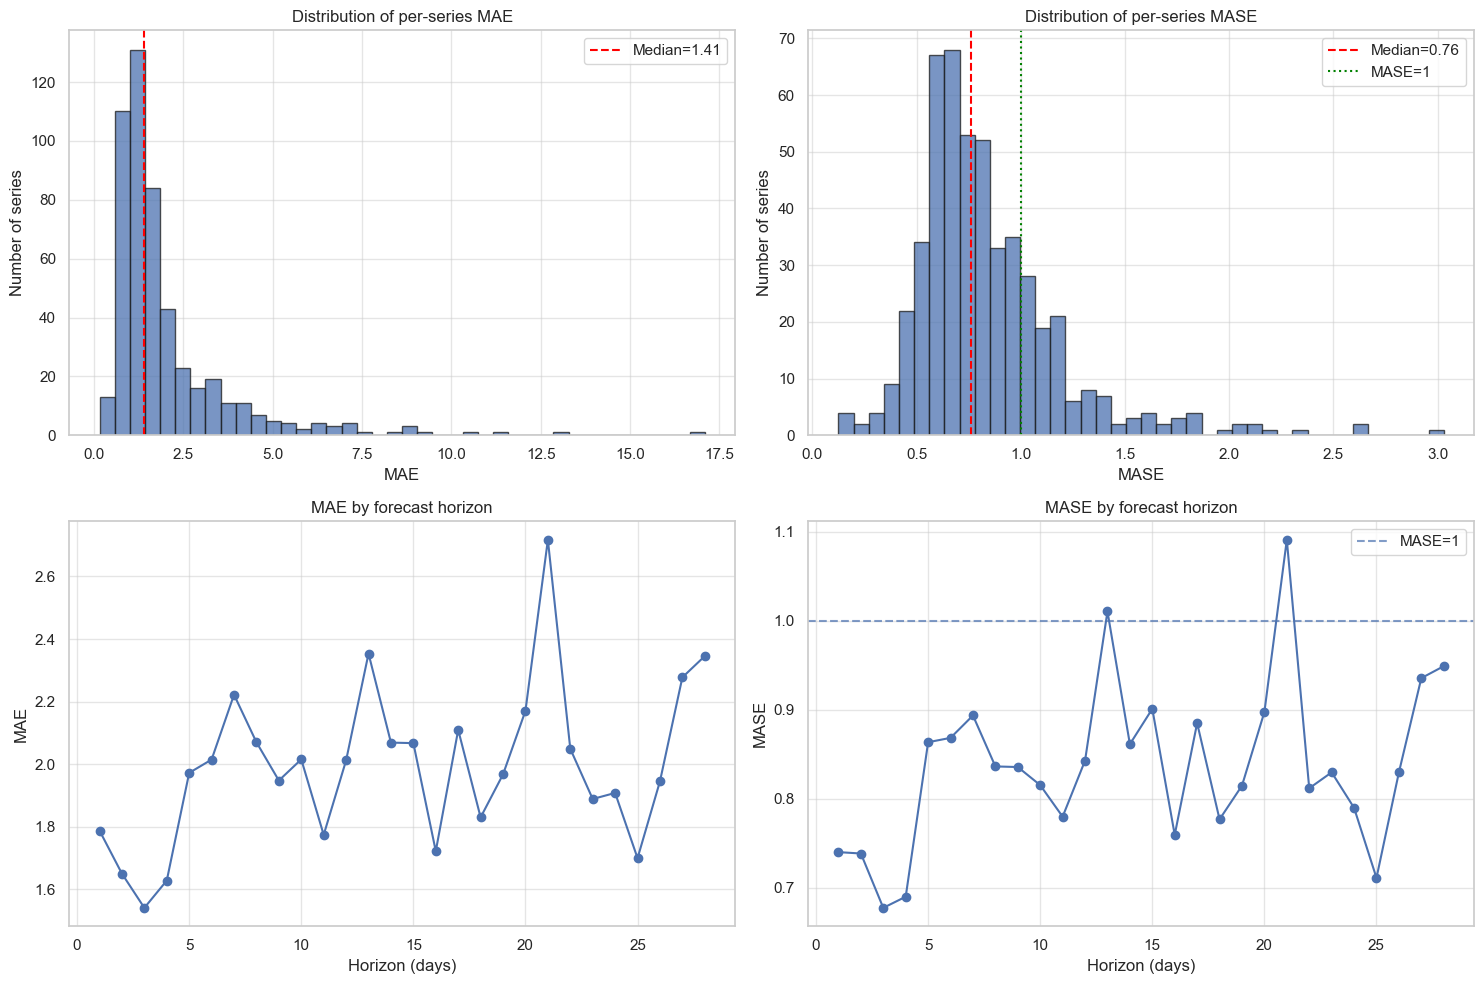

Series with MASE < 1 (better than weekly naive): 76.6%


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of MAE by series
axes[0, 0].hist(sensor_metrics["MAE"], bins=40, edgecolor="k", alpha=0.75)
axes[0, 0].axvline(sensor_metrics["MAE"].median(), linestyle="--", color="red",
                   label=f"Median={sensor_metrics['MAE'].median():.2f}")
axes[0, 0].set_title("Distribution of per-series MAE")
axes[0, 0].set_xlabel("MAE")
axes[0, 0].set_ylabel("Number of series")
axes[0, 0].legend()

# Distribution of MASE by series
valid_mase = sensor_metrics["MASE"].dropna()
axes[0, 1].hist(valid_mase, bins=40, edgecolor="k", alpha=0.75)
axes[0, 1].axvline(valid_mase.median(), linestyle="--", color="red",
                   label=f"Median={valid_mase.median():.2f}")
axes[0, 1].axvline(1.0, linestyle=":", color="green", label="MASE=1")
axes[0, 1].set_title("Distribution of per-series MASE")
axes[0, 1].set_xlabel("MASE")
axes[0, 1].set_ylabel("Number of series")
axes[0, 1].legend()

# MAE by horizon
axes[1, 0].plot(horizon_metrics["horizon"], horizon_metrics["MAE"], marker="o")
axes[1, 0].set_title("MAE by forecast horizon")
axes[1, 0].set_xlabel("Horizon (days)")
axes[1, 0].set_ylabel("MAE")

# MASE by horizon
axes[1, 1].plot(horizon_metrics["horizon"], horizon_metrics["MASE"], marker="o")
axes[1, 1].axhline(1.0, linestyle="--", alpha=0.7, label="MASE=1")
axes[1, 1].set_title("MASE by forecast horizon")
axes[1, 1].set_xlabel("Horizon (days)")
axes[1, 1].set_ylabel("MASE")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

pct_beats_naive = (valid_mase < 1.0).mean() * 100 if len(valid_mase) > 0 else np.nan
print(f"Series with MASE < 1 (better than weekly naive): {pct_beats_naive:.1f}%")

## 12. Representative series and aggregated holdout demand

Series selected for plotting:
  HOUSEHOLD_1_087_WI_3 | cumulative historical sales=1871
  HOUSEHOLD_1_048_TX_2 | cumulative historical sales=3726
  FOODS_1_173_CA_3 | cumulative historical sales=13334


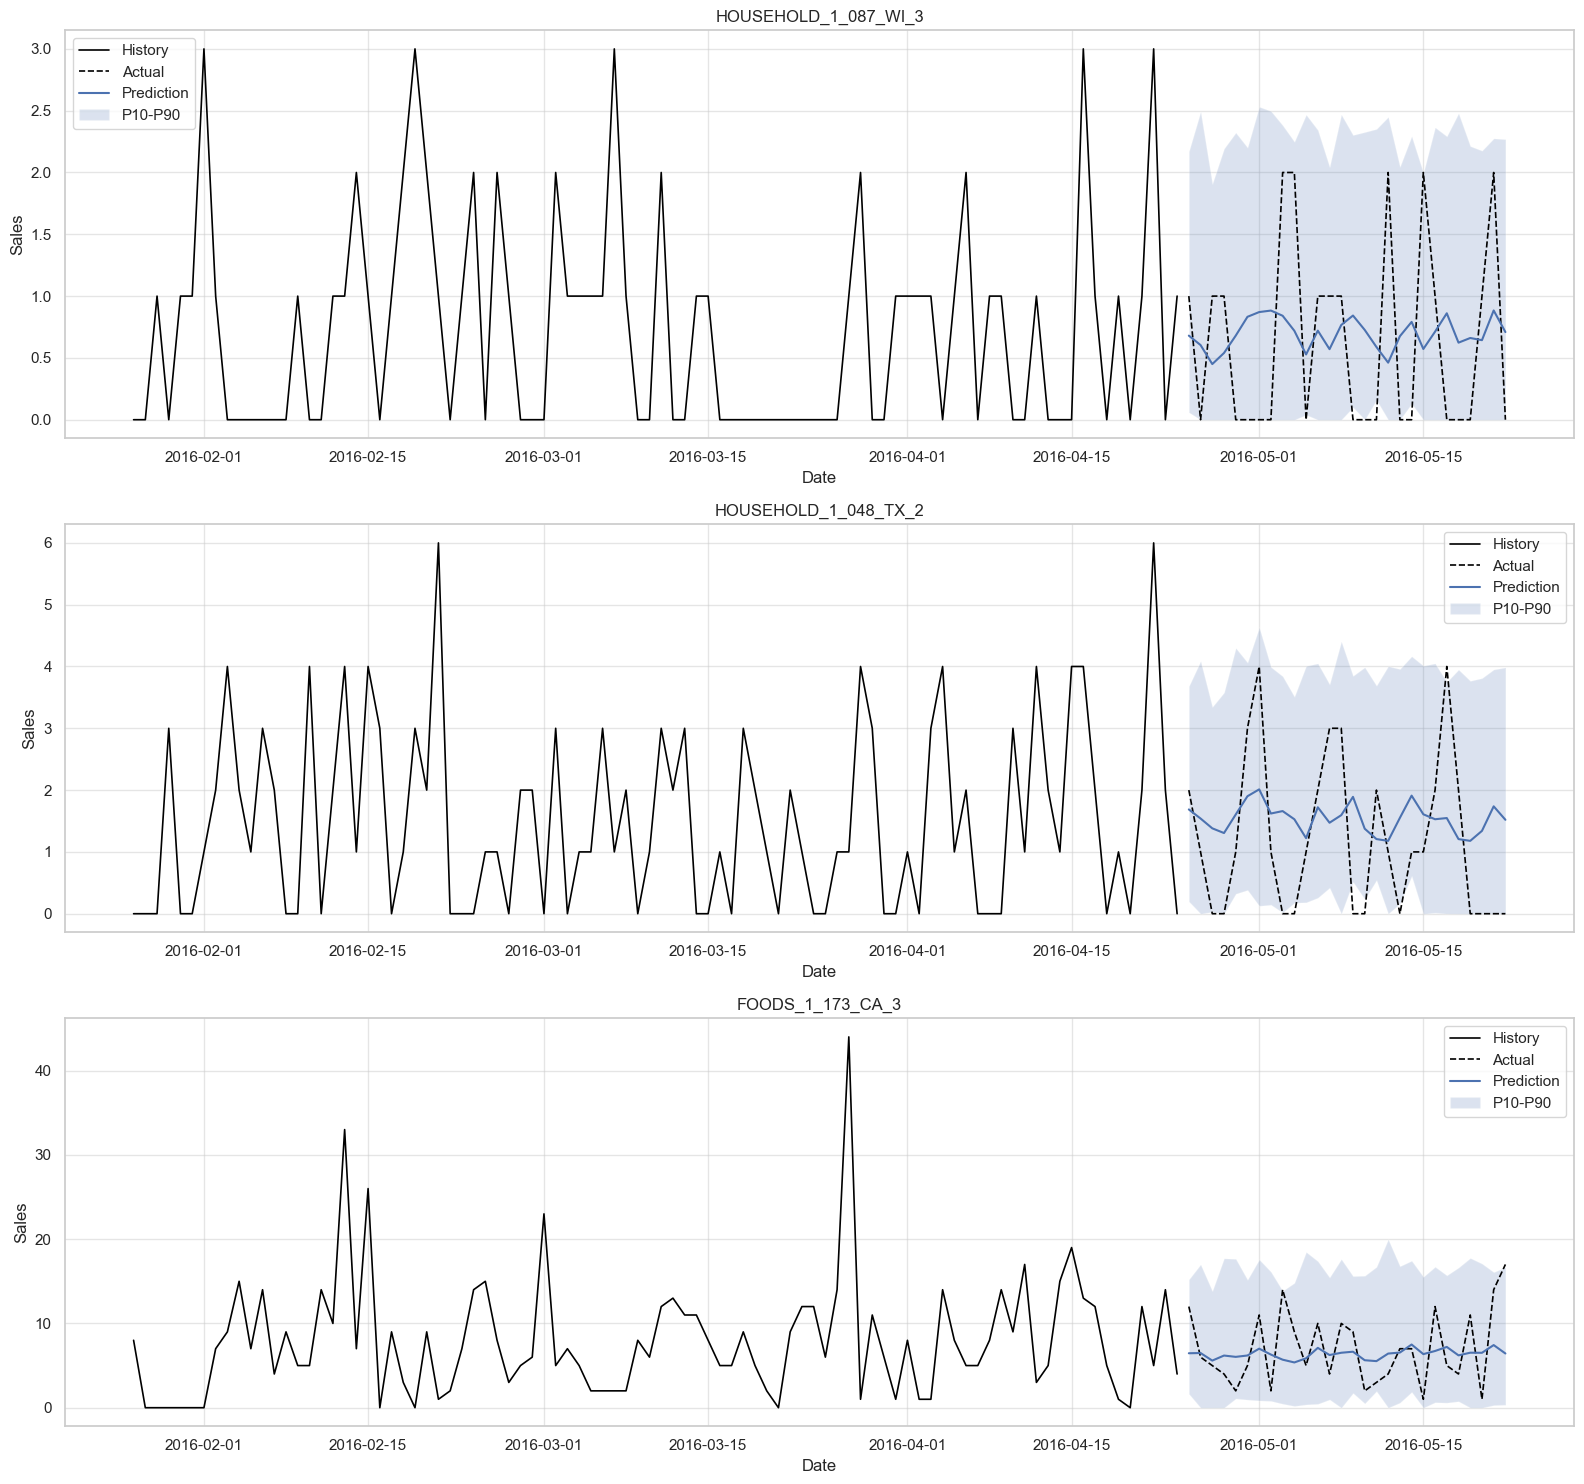

In [33]:
activity = (
    context_df.groupby(ID_COL)[TARGET]
    .sum()
    .sort_values()
)

active_ids = activity[activity > 0].index.tolist()
if len(active_ids) < 3:
    sample_ids = active_ids
else:
    sample_ids = [
        active_ids[len(active_ids) // 10],
        active_ids[len(active_ids) // 2],
        active_ids[9 * len(active_ids) // 10],
    ]

print("Series selected for plotting:")
for sid in sample_ids:
    print(f"  {sid} | cumulative historical sales={activity[sid]:.0f}")

history_plot_days = 90
q10_col = quantile_col_map.get(0.1)
q90_col = quantile_col_map.get(0.9)

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(16, 5 * max(len(sample_ids), 1)), sharex=False)
if len(sample_ids) == 1:
    axes = [axes]

for ax, series_id in zip(axes, sample_ids):
    hist = (
        context_df[context_df[ID_COL] == series_id]
        .sort_values(TS_COL)
        .tail(history_plot_days)
    )
    pred = (
        eval_df[eval_df[ID_COL] == series_id]
        .sort_values(TS_COL)
    )

    ax.plot(hist[TS_COL], hist[TARGET], color="black", linewidth=1.2, label="History")
    ax.plot(pred[TS_COL], pred[TARGET], color="black", linestyle="--", linewidth=1.2, label="Actual")
    ax.plot(pred[TS_COL], pred["predictions"], linewidth=1.5, label="Prediction")

    if q10_col is not None and q90_col is not None:
        ax.fill_between(
            pred[TS_COL],
            pred[q10_col].astype(float),
            pred[q90_col].astype(float),
            alpha=0.2,
            label="P10-P90",
        )

    ax.set_title(series_id)
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()

plt.tight_layout()
plt.show()

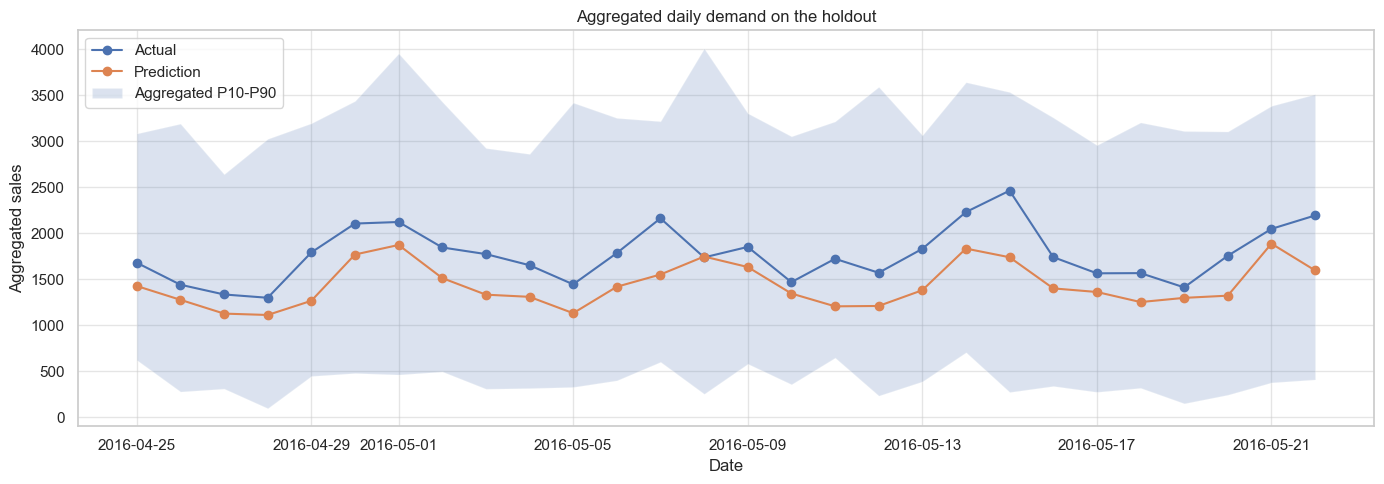

,timestamp,actual,prediction,p10,p90
0,2016-04-25,1678.0,1424.900196,620.095447,3083.379780
1,2016-04-26,1439.0,1274.952315,276.984000,3190.420999
2,2016-04-27,1333.0,1124.846081,308.810379,2641.373807
3,2016-04-28,1297.0,1109.907011,95.637497,3025.374190
4,2016-04-29,1790.0,1264.046159,446.361915,3195.270520


In [34]:
daily_total = (
    eval_df.groupby(TS_COL)
    .agg(
        actual=(TARGET, "sum"),
        prediction=("predictions", "sum"),
    )
    .reset_index()
)

if q10_col is not None:
    daily_total["p10"] = eval_df.groupby(TS_COL)[q10_col].sum().values
if q90_col is not None:
    daily_total["p90"] = eval_df.groupby(TS_COL)[q90_col].sum().values

plt.figure(figsize=(14, 5))
plt.plot(daily_total[TS_COL], daily_total["actual"], marker="o", label="Actual")
plt.plot(daily_total[TS_COL], daily_total["prediction"], marker="o", label="Prediction")

if "p10" in daily_total.columns and "p90" in daily_total.columns:
    plt.fill_between(
        daily_total[TS_COL],
        daily_total["p10"],
        daily_total["p90"],
        alpha=0.2,
        label="Aggregated P10-P90",
    )

plt.title("Aggregated daily demand on the holdout")
plt.xlabel("Date")
plt.ylabel("Aggregated sales")
plt.legend()
plt.tight_layout()
plt.show()

display(daily_total.head())

## 13. Training loss curve

,epoch,lr-Adam,step,train_loss_epoch,train_loss_step,val_MAE,val_RMSE,val_SMAPE,val_loss
235,7.0,NaN,10699,NaN,1.194808,NaN,NaN,NaN,NaN
236,7.0,NaN,10749,NaN,1.438141,NaN,NaN,NaN,NaN
237,7.0,NaN,10799,NaN,1.294149,NaN,NaN,NaN,NaN
238,7.0,NaN,10807,NaN,NaN,1.999176,3.636292,0.949879,1.29147
239,7.0,NaN,10807,1.319812,NaN,NaN,NaN,NaN,NaN



Validation loss by epoch:


,epoch,val_loss
28,0.0,1.315677
58,1.0,1.298982
88,2.0,1.270389
118,3.0,1.276013
148,4.0,1.273650
178,5.0,1.279959
208,6.0,1.277292
238,7.0,1.291470


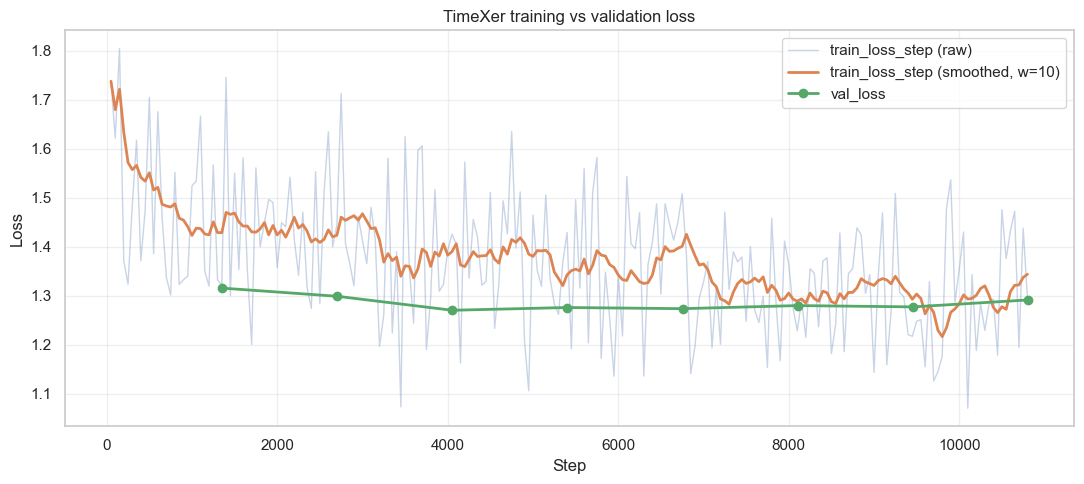

In [35]:
metrics_csv_path = os.path.join(logger.log_dir, "metrics.csv")

if os.path.exists(metrics_csv_path):
    metrics_log = pd.read_csv(metrics_csv_path)

    display(metrics_log.tail())

    plt.figure(figsize=(11, 5))

    has_any_curve = False

    # -------------------------
    # Train loss by step
    # -------------------------
    if {"step", "train_loss_step"}.issubset(metrics_log.columns):
        train_curve = metrics_log[["step", "train_loss_step"]].dropna().sort_values("step")
        if len(train_curve) > 0:
            plt.plot(
                train_curve["step"],
                train_curve["train_loss_step"],
                label="train_loss_step (raw)",
                alpha=0.30,
                linewidth=1
            )

            # Smoothed train curve
            smooth_window = max(5, min(50, len(train_curve) // 20))
            train_curve["train_loss_smooth"] = (
                train_curve["train_loss_step"]
                .rolling(window=smooth_window, min_periods=1)
                .mean()
            )

            plt.plot(
                train_curve["step"],
                train_curve["train_loss_smooth"],
                label=f"train_loss_step (smoothed, w={smooth_window})",
                linewidth=2
            )
            has_any_curve = True

    # -------------------------
    # Validation loss by step
    # -------------------------
    if {"step", "val_loss"}.issubset(metrics_log.columns):
        val_curve = metrics_log[["step", "val_loss"]].dropna().sort_values("step")
        if len(val_curve) > 0:
            plt.plot(
                val_curve["step"],
                val_curve["val_loss"],
                label="val_loss",
                marker="o",
                linewidth=2
            )
            has_any_curve = True

    # -------------------------
    # Validation loss by epoch
    # -------------------------
    if {"epoch", "val_loss"}.issubset(metrics_log.columns):
        val_epoch_curve = metrics_log[["epoch", "val_loss"]].dropna().drop_duplicates().sort_values("epoch")
        if len(val_epoch_curve) > 0:
            print("\nValidation loss by epoch:")
            display(val_epoch_curve.tail(10))

    if has_any_curve:
        plt.title("TimeXer training vs validation loss")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("metrics.csv exists, but no usable train/validation loss columns were found.")
        print("Available columns:")
        print(metrics_log.columns.tolist())

else:
    print(f"Could not find metrics CSV: {metrics_csv_path}")

## 14. Save outputs

Saved files mirror the Chronos-2 notebook as closely as possible so later comparison is easy.

In [36]:
OUTPUT_DIR = os.path.join(DATA_DIR, "timexer_m5_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

forecast_path = os.path.join(OUTPUT_DIR, "m5_forecast_raw.csv")
eval_path = os.path.join(OUTPUT_DIR, "m5_eval_predictions_vs_actuals.csv")
sensor_metrics_path = os.path.join(OUTPUT_DIR, "m5_sensor_metrics.csv")
horizon_metrics_path = os.path.join(OUTPUT_DIR, "m5_horizon_metrics.csv")
global_metrics_path = os.path.join(OUTPUT_DIR, "m5_global_metrics.csv")
training_log_path = os.path.join(OUTPUT_DIR, "m5_training_metrics.csv")

forecast_df.to_csv(forecast_path, index=False)
eval_df.to_csv(eval_path, index=False)
sensor_metrics.to_csv(sensor_metrics_path, index=False)
horizon_metrics.to_csv(horizon_metrics_path, index=False)
global_metrics.to_csv(global_metrics_path)

if os.path.exists(metrics_csv_path):
    pd.read_csv(metrics_csv_path).to_csv(training_log_path, index=False)

print("Files saved:")
print("-", forecast_path)
print("-", eval_path)
print("-", sensor_metrics_path)
print("-", horizon_metrics_path)
print("-", global_metrics_path)
if os.path.exists(metrics_csv_path):
    print("-", training_log_path)

Files saved:
- dataset/processed/timexer_m5_outputs/m5_forecast_raw.csv
- dataset/processed/timexer_m5_outputs/m5_eval_predictions_vs_actuals.csv
- dataset/processed/timexer_m5_outputs/m5_sensor_metrics.csv
- dataset/processed/timexer_m5_outputs/m5_horizon_metrics.csv
- dataset/processed/timexer_m5_outputs/m5_global_metrics.csv
- dataset/processed/timexer_m5_outputs/m5_training_metrics.csv


## Next natural steps

1. Run the notebook with the **same `m5_selected_ids.csv`** used by Chronos-2.
2. Compare global metrics and per-series distributions side by side.
3. If runtime allows it, increase:
   - `MAX_SERIES`
   - `TRAIN_HISTORY_DAYS`
   - or `ENCODER_LENGTH`
4. Optionally add a simple **naive-7** baseline to contextualize both models.

## 15. Conclusiones

### 15.1 Resumen del enfoque

Este notebook entrena y evalúa **TimeXer** (pytorch-forecasting ≥ 1.4) sobre el subconjunto M5 Forecasting Accuracy con una evaluación de holdout fijo de **28 días** (2016-04-25 → 2016-05-22), replicando el protocolo del notebook de Chronos-2 para permitir una comparación directa.

TimeXer es un modelo **supervisado** basado en transformers con tokenización por parches. Para cada parche de 7 días del encoder, un token endógeno captura la dinámica temporal histórica; los tokens exógenos inyectan covariables conocidas futuras (`sell_price`, `snap`, `wday`, `month`, `event_any`, `event_type_main`). La red genera cuantiles `[0.1, 0.5, 0.9]` para cada paso del horizonte.

- **Series**: 500 series (mismas IDs que Chronos-2, `dense_random`, top 25 % por `nonzero_ratio`, `seed=42`)
- **Encoder**: 1,456 días de historia (208 semanas) con `patch_length=7` (208 parches por serie)
- **Parámetros del modelo**: 16.0 M
- **Hardware**: Apple Silicon MPS, `precision=32-true`
- **Inferencia** sobre el holdout de 500 series: **1.67 s**

---

### 15.2 Parámetros configurables

| Parámetro | Valor | Descripción |
|---|---|---|
| `PREDICTION_LENGTH` | 28 | Horizonte de predicción en días |
| `ENCODER_LENGTH` | 1,456 | Ventana de historia del encoder (208 semanas) |
| `PATCH_LENGTH` | 7 | Longitud de cada parche temporal (1 semana) |
| `VAL_LENGTH` | 28 | Cola de validación tomada del histórico |
| `TRAIN_HISTORY_DAYS` | 8,192 | Máximo de días históricos por serie |
| `MAX_SERIES` | 500 | Número de series seleccionadas |
| `BATCH_SIZE` | 128 | Tamaño del batch |
| `MAX_EPOCHS` | 50 | Épocas máximas (EarlyStopping activo) |
| `PATIENCE` | 4 | Paciencia EarlyStopping sobre `val_MAE` |
| `LEARNING_RATE` | 1 × 10⁻⁴ | Tasa de aprendizaje inicial |
| `HIDDEN_SIZE` | 512 | Dimensión del espacio latente |
| `N_HEADS` | 4 | Cabezas de atención multi-head |
| `E_LAYERS` | 2 | Capas del encoder Transformer |
| `D_FF` | 1,024 | Dimensión del feed-forward |
| `DROPOUT` | 0,1 | Tasa de dropout |
| `MASE_SEASONALITY` | 7 | Estacionalidad para el naïve de referencia (semanal) |
| `LAGS` | [7, 14, 28, 56] | Lags de la variable objetivo como covariable |

---

### 15.3 Entrenamiento y tiempo de cómputo

El entrenamiento convergió en **8 épocas** (EarlyStopping disparado tras 4 épocas sin mejora a partir de la época 3):

| Época | val_MAE | Estado |
|---|---|---|
| 0 | 2.025 | – |
| 1 | 2.007 | mejora |
| 2 | 1.980 | mejora |
| **3** | **1.973** | ✅ Mejor checkpoint |
| 4 | ≈1.979 | sin mejora |
| 5 | ≈1.980 | sin mejora |
| 6 | ≈1.981 | sin mejora |
| 7 | ≈1.982 | sin mejora → STOP |

- **Tiempo total de entrenamiento**: 59 min 34 s (≈ 7.5 min/época × 8 épocas, MPS)
- **Tiempo de inferencia** (500 series × 28 días): **1.67 s** en MPS
- **Parámetros entrenables**: 16,048 k (16.0 M)
- **Normalización**: `GroupNormalizer` por serie; salida en cuantiles

---

### 15.4 Rendimiento global

Métricas calculadas sobre las 500 series × 28 días de holdout (14,000 puntos):

| Métrica | Valor |
|---|---|
| MAE | **1.992** unidades/día |
| RMSE | 3.558 unidades/día |
| sMAPE | 90.7 % |
| WAPE | 0.563 |
| **MASE** | **0.837** |
| WQL | 0.363 |

Un MASE = 0.837 indica que TimeXer supera al **naïve semanal** (lag-7) en un 16.3 % de media.

---

### 15.5 Rendimiento por horizonte temporal

Métricas promediadas por semana del horizonte de 28 días:

| Semana | Días | MAE | MASE |
|---|---|---|---|
| Semana 1 | 1 – 7 | 1.815 | 0.788 |
| Semana 2 | 8 – 14 | 2.037 | 0.851 |
| Semana 3 | 15 – 21 | 2.069 | 0.881 |
| Semana 4 | 22 – 28 | 2.046 | 0.853 |

- El **día 3** registra el menor MASE del horizonte (0.678).
- El **día 13** (MASE=1.010) y el **día 21** (MASE=1.091) superan la barrera del naïve, coincidiendo con transiciones semanales en el holdout.
- La degradación entre semanas es moderada (≈ 12 % de W1 a W3), sin colapso en horizontes largos.

---

### 15.6 Rendimiento por serie

| Estadístico | MAE | MASE |
|---|---|---|
| Mínimo | 0.153 | 0.125 |
| Percentil 25 | 1.004 | 0.611 |
| Mediana | 1.409 | 0.761 |
| Media | 1.992 | 0.837 |
| Percentil 75 | 2.206 | 0.972 |
| Máximo | 17.09 | 3.029 |

- **76.6 %** de las series alcanzan MASE < 1 (mejor que el naïve semanal).
- La mediana de MASE (0.761) es notablemente mejor que la media (0.837), lo que indica que la distribución está sesgada por un pequeño número de series con alta variabilidad.
- Las series con mayor MAE absoluto corresponden a ítems de alto volumen (`FOODS_2_326_WI_2` con MAE=17.09, `FOODS_3_086_WI_3` con MAE=13.21), donde errores unitarios son mayores por naturaleza.

---

### 15.7 Comparación de variantes TimeXer y Chronos-2 en M5

Todos los modelos se evalúan sobre las **mismas 500 series** y el **mismo holdout de 28 días**.

| Métrica | Chronos-2 (zero-shot, 1456H) | TimeXer 1092H | TimeXer 1456H |
|---|---|---|---|
| MAE | 1.938 | 1.981 | 1.992 |
| RMSE | 3.435 | 3.498 | 3.558 |
| **MASE** | **0.829** | 0.838 | 0.837 |
| WQL | 0.353 | 0.358 | 0.363 |
| sMAPE (%) | 97.2 | **90.7** | **90.7** |
| Series MASE < 1 | 76.0 % | **77.0 %** | 76.6 % |
| Entrenamiento | 0 s *(zero-shot)* | ≈ 1.5 h | ≈ 1 h |
| Inferencia (500 series) | 24.3 s | 1.24 s | **1.67 s** |
| Parámetros | – | 13.6 M | 16.0 M |

Ampliar el encoder de 1,092 a 1,456 días **no aporta mejora** en MASE (0.838 → 0.837, diferencia < 0.2 %), mientras que aumenta el número de parámetros en un 18 % (13.6 M → 16.0 M) y el tiempo de inferencia en un 35 %. Los tres modelos son estadísticamente equivalentes en MASE. La única ventaja robusta de TimeXer frente a Chronos-2 es la inferencia más rápida.

---

### 15.8 Valoración global

**Fortalezas de TimeXer en M5 (1456H):**
- Paridad de rendimiento con Chronos-2 y con la variante de 1,092 días sin necesidad de un modelo de fundación pre-entrenado.
- Inferencia rápida (1.67 s para 500 series × 28 días), útil en producción.
- sMAPE 6.5 puntos porcentuales mejor que Chronos-2 (90.7 % vs 97.2 %).
- El 76.6 % de las series supera al naïve semanal, confirmando que el modelo aprende patrones relevantes.

**Limitaciones:**
- El entrenamiento requiere **≈ 1 hora** en Apple Silicon MPS, frente a los 0 segundos de Chronos-2 en modo zero-shot.
- Ampliar el encoder de 1,092 a 1,456 días **no mejora** el MASE, lo que sugiere rendimientos decrecientes al extender el contexto más allá de 3 años en este dominio.
- El mejor checkpoint se obtiene en la **época 3**, convergencia temprana que sugiere saturación de capacidad del encoder.
- La ventaja sobre el naïve semanal es modesta (MASE = 0.837), sin diferencia práctica respecto a la variante de 1,092 días (MASE = 0.838).
- En el dominio retail M5, **la supervisión no aporta ventaja medible** sobre el enfoque zero-shot, cuestionando la relación coste/beneficio del entrenamiento.

**Conclusión general:**
Las tres configuraciones evaluadas (Chronos-2 zero-shot, TimeXer 1092H y TimeXer 1456H) alcanzan resultados estadísticamente equivalentes en MASE sobre 500 series densas del M5. Ampliar el encoder de TimeXer de 1,092 a 1,456 días no produce mejora de rendimiento, confirmando que el modelo no aprovecha contexto adicional más allá de 3 años. Chronos-2 es la opción preferible cuando se prioriza simplicidad operacional. TimeXer es preferible cuando se requiere latencia de inferencia mínima en producción.